In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

In [3]:
df = pd.read_csv("ai_student_impact_dataset.csv")

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [6]:
df[['Tool_Diversity', 'Weekly_GenAI_Hours']].head()

,Tool_Diversity,Weekly_GenAI_Hours
0,1,23.31
1,5,1.12
2,2,21.26
3,4,1.82
4,4,9.29


In [7]:
df[['Tool_Diversity', 'Weekly_GenAI_Hours']].isnull().sum()

Tool_Diversity        0
Weekly_GenAI_Hours    0
dtype: int64

In [8]:
df[['Tool_Diversity', 'Weekly_GenAI_Hours']].describe()

,Tool_Diversity,Weekly_GenAI_Hours
count,50000.00000,50000.000000
mean,2.80026,8.427752
std,1.18802,8.269490
min,1.00000,0.000000
25%,2.00000,2.390000
50%,3.00000,5.800000
75%,4.00000,11.720000
max,5.00000,40.000000


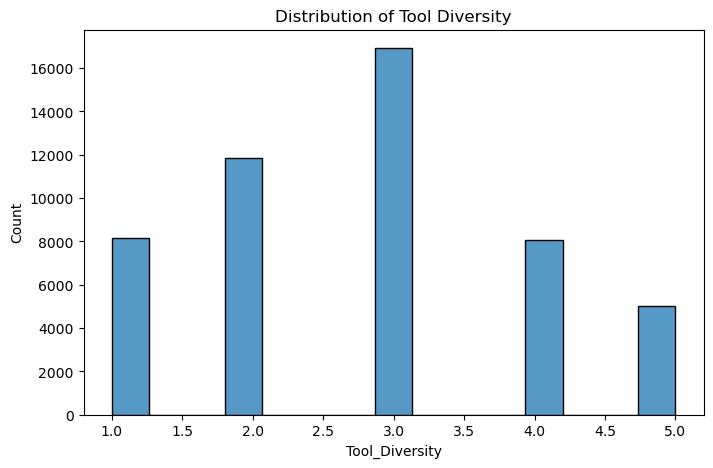

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tool_Diversity'], bins=15)
plt.title('Distribution of Tool Diversity')
plt.show()

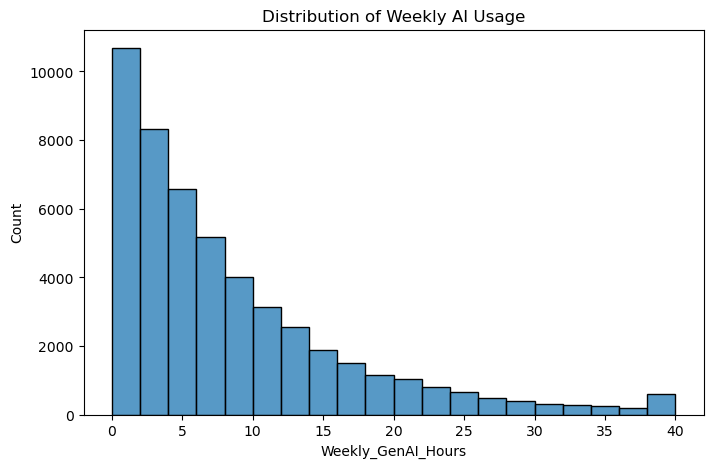

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Weekly_GenAI_Hours'], bins=20)
plt.title('Distribution of Weekly AI Usage')
plt.show()

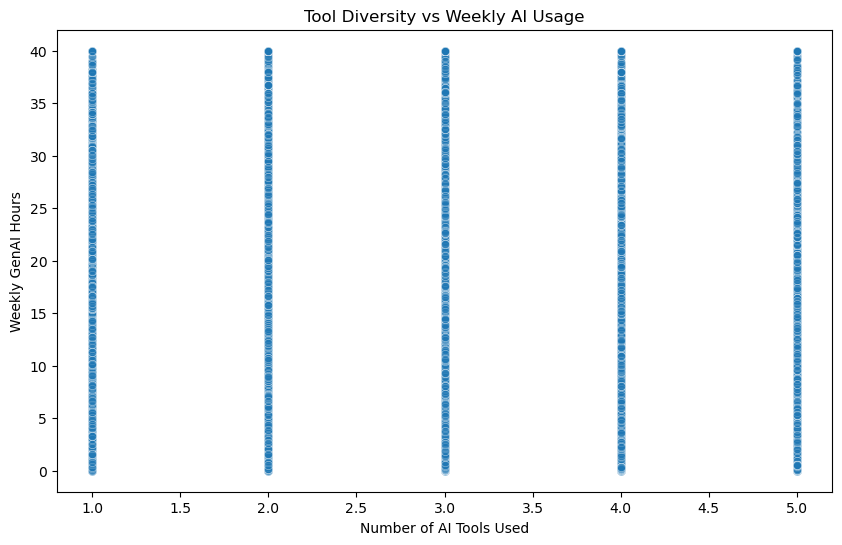

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Tool_Diversity',
    y='Weekly_GenAI_Hours',
    alpha=0.5
)

plt.title('Tool Diversity vs Weekly AI Usage')
plt.xlabel('Number of AI Tools Used')
plt.ylabel('Weekly GenAI Hours')

plt.show()

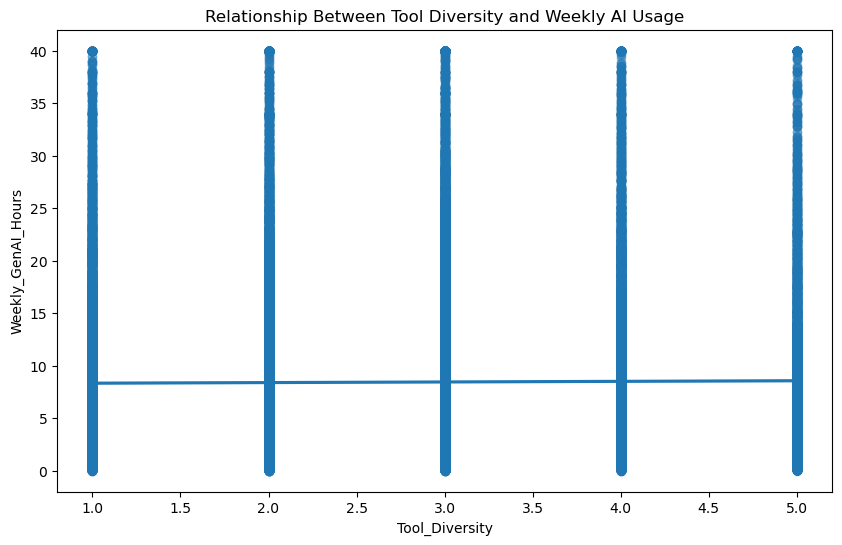

In [12]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Tool_Diversity',
    y='Weekly_GenAI_Hours',
    scatter_kws={'alpha':0.3}
)

plt.title('Relationship Between Tool Diversity and Weekly AI Usage')

plt.show()

In [13]:
corr, p_value = pearsonr(
    df['Tool_Diversity'],
    df['Weekly_GenAI_Hours']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.008410604005358186
P-value: 0.06001893682695559


In [15]:
df[cols].dtypes

Weekly_GenAI_Hours          float64
Tool_Diversity                int64
Prompt_Engineering_Skill     object
Skill_Retention_Score       float64
Perceived_AI_Dependency       int64
dtype: object

In [16]:
for col in cols:
    print(col)
    print(df[col].unique()[:10])
    print("-"*30)

Weekly_GenAI_Hours
[23.31  1.12 21.26  1.82  9.29  6.5  31.41  5.33  2.   19.99]
------------------------------
Tool_Diversity
[1 5 2 4 3]
------------------------------
Prompt_Engineering_Skill
['Beginner' 'Advanced' 'Intermediate']
------------------------------
Skill_Retention_Score
[ 86.44  69.39  73.93  63.58 100.    65.92  67.97  85.09  55.71  87.18]
------------------------------
Perceived_AI_Dependency
[ 5  3  2  4  8  1  6  7 10  9]
------------------------------


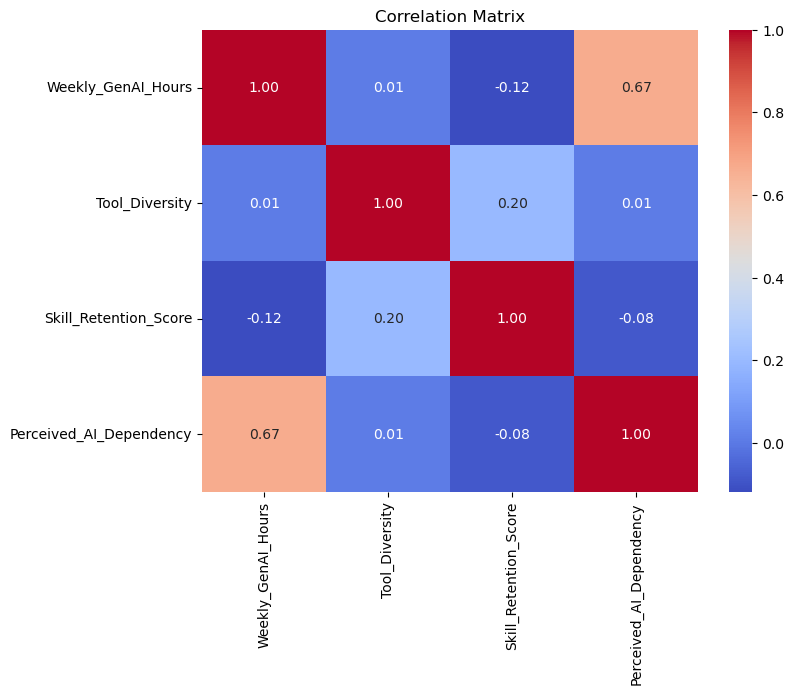

In [17]:
cols = [
    'Weekly_GenAI_Hours',
    'Tool_Diversity',
    'Skill_Retention_Score',
    'Perceived_AI_Dependency'
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [19]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['Tool_Diversity'],
    df['Weekly_GenAI_Hours']
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: 0.008
P-value: 0.06001893682695559


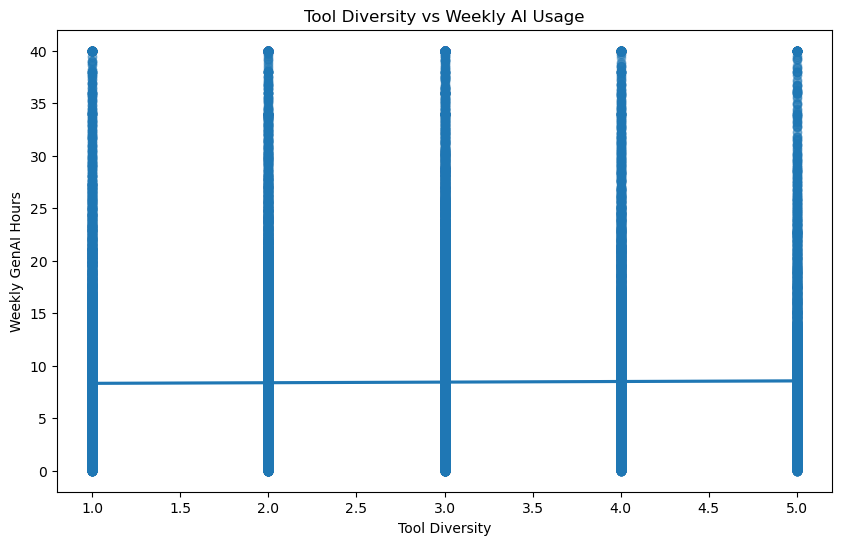

In [20]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Tool_Diversity',
    y='Weekly_GenAI_Hours',
    scatter_kws={'alpha':0.3}
)

plt.title('Tool Diversity vs Weekly AI Usage')
plt.xlabel('Tool Diversity')
plt.ylabel('Weekly GenAI Hours')

plt.show()

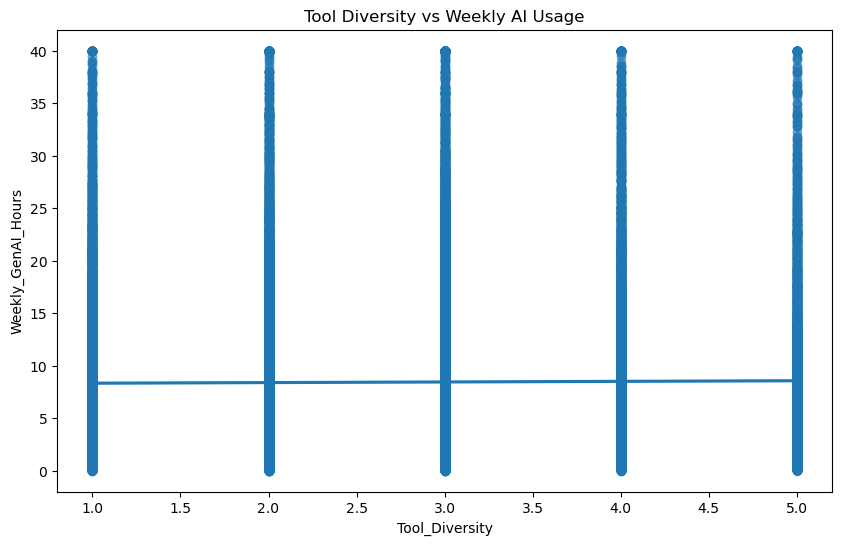

In [21]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Tool_Diversity',
    y='Weekly_GenAI_Hours',
    scatter_kws={'alpha':0.3}
)

plt.title('Tool Diversity vs Weekly AI Usage')

plt.savefig(
    'tool_diversity_vs_ai_usage.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

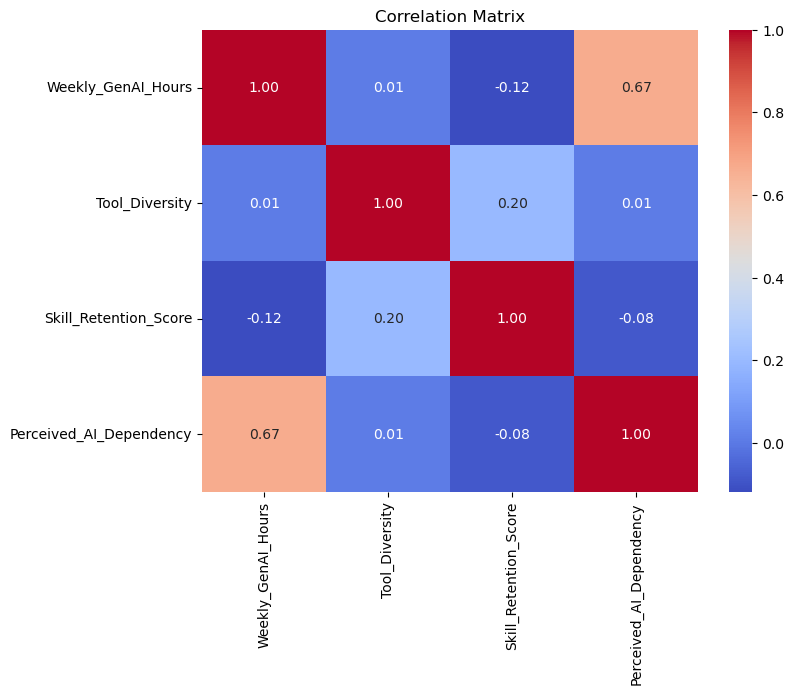

In [23]:
cols = [
    'Weekly_GenAI_Hours',
    'Tool_Diversity',
    'Skill_Retention_Score',
    'Perceived_AI_Dependency'
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [24]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['Tool_Diversity'],
    df['Weekly_GenAI_Hours']
)

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")

Correlation: 0.008
P-value: 0.06002
